## ml_v12 : 복합 지수 Y값 (정규화 평점 × 정규화 log_review_count)
* Y값: (평점/5) × (log1p(리뷰수)/max) → quantile 30/70 이진화
* PCA 완전 제거 (KMO=0.0001, Bartlett p=0.55 → PCA 부적합 판정)
* 질(평점) + 양(리뷰수) 명시적 가중 곱 — PCA 대체
* 나머지 피처/파이프라인은 ml_v6과 동일

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
import re, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_PATH = r"C:\workspace\finalproject\data\ml_AmazonSephoraUlta.csv"
df_all = pd.read_csv(DATA_PATH, encoding='utf-8-sig', low_memory=False)

df_all['카테고리(중)'] = df_all['카테고리(중)'].str.lower().str.strip()

print(f"전체: {len(df_all)}개")
print(f"플랫폼별:\n{df_all['store_id'].str.split('_').str[0].value_counts().to_string()}")
print(f"\n리뷰수 있음: {df_all['리뷰수'].notna().sum()}개")
print(f"평점 있음:   {df_all['평점'].notna().sum()}개")
print(f"\ntarget_category 분포:\n{df_all['target_category'].value_counts().to_string()}")

c:\Users\asiae\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\asiae\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


전체: 5964개
플랫폼별:
store_id
amazon     2560
sephora    1802
ulta       1602

리뷰수 있음: 5929개
평점 있음:   5929개

target_category 분포:
target_category
skincare     3963
cleansing    1037
suncare       551
masks         413


In [2]:
# ── Y값: 정규화(평점) × 정규화(log_review_count) → 극단 30% 이진분류
# PCA 제거 근거: KMO=0.0001(부적합), Bartlett p=0.55(비유의), 음의 상관
# 복합 지수 = 질(평점) × 양(리뷰수) → 두 변수의 특성을 명시적으로 반영
df_y = df_all[
    df_all['리뷰수'].notna() &
    df_all['평점'].notna() &
    (df_all['평점'] <= 5)
].copy()

log_review             = np.log1p(df_y['리뷰수'])
df_y['y_rating_norm']  = df_y['평점'] / 5.0
df_y['y_review_norm']  = log_review / log_review.max()
df_y['y_composite']    = df_y['y_rating_norm'] * df_y['y_review_norm']

th_lo = df_y['y_composite'].quantile(0.30)
th_hi = df_y['y_composite'].quantile(0.70)
mask  = (df_y['y_composite'] <= th_lo) | (df_y['y_composite'] >= th_hi)
df_y  = df_y[mask].copy()
df_y['target'] = (df_y['y_composite'] >= th_hi).astype(int)

print(f"복합 지수 분포:")
print(f"  비인기 (하위 30%) 임계값: {th_lo:.4f}")
print(f"  인기   (상위 30%) 임계값: {th_hi:.4f}")
print(f"\n학습 데이터: {len(df_y)}개  (긍정={df_y['target'].sum()}, 부정={len(df_y)-df_y['target'].sum()})")
print(f"플랫폼별:\n{df_y['store_id'].str.split('_').str[0].value_counts().to_string()}")

복합 지수 분포:
  비인기 (하위 30%) 임계값: 0.2639
  인기   (상위 30%) 임계값: 0.4533

학습 데이터: 3546개  (긍정=1773, 부정=1773)
플랫폼별:
store_id
amazon     1615
ulta       1006
sephora     925


In [3]:
# ── 피처 생성
ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
df_y['ingredient_text'] = df_y[ing_cols].fillna('').agg(' '.join, axis=1).str.strip()
ing_lower = df_y['ingredient_text'].str.lower()

# 용량(ml)
def extract_ml(s):
    if pd.isna(s): return np.nan
    m = re.search(r'([\d.]+)\s*ml', str(s), re.IGNORECASE)
    if m: return float(m.group(1))
    m = re.search(r'([\d.]+)\s*oz', str(s), re.IGNORECASE)
    if m: return float(m.group(1)) * 29.5735
    return np.nan
df_y['volume_ml'] = df_y['용량'].apply(extract_ml)

# 가격대
price_d = pd.get_dummies(
    pd.cut(df_y['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_y = pd.concat([df_y, price_d], axis=1)

# 카테고리(대) 원핫
cat_d = pd.get_dummies(df_y['target_category'], prefix='cat').astype(int)
df_y = pd.concat([df_y, cat_d], axis=1)

# 카테고리(중) 원핫 (n<50 제거)
mid_counts = df_y['카테고리(중)'].value_counts()
valid_mid  = mid_counts[mid_counts >= 50].index
df_y['cat_mid'] = df_y['카테고리(중)'].where(df_y['카테고리(중)'].isin(valid_mid), other='기타')
mid_d = pd.get_dummies(df_y['cat_mid'], prefix='mid').astype(int)
df_y = pd.concat([df_y, mid_d], axis=1)

# K뷰티 성분
kbeauty_map = {
    'k_galactomyces': 'galactomyces', 'k_bifida':      'bifida',
    'k_centella':     'centella',     'k_ginseng':     'ginseng',
    'k_snail':        'snail',        'k_beta_glucan': 'beta-glucan',
    'k_bakuchiol':    'bakuchiol',    'k_pdrn':        'polydeoxyribonucleotide|pdrn',
    'k_propolis':     'propolis',
}
for feat, kw in kbeauty_map.items():
    df_y[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
k_cols = list(kbeauty_map.keys())
df_y['k_beauty_ratio'] = df_y[k_cols].sum(axis=1) / len(k_cols)

# US 트렌드 성분 20개 (EDA 기반)
gt_map = {
    'gt_tocopherol':        'tocopherol',
    'gt_tocopheryl_acetate':'tocopheryl acetate',
    'gt_sodium_hyaluronate':'sodium hyaluronate',
    'gt_niacinamide':       'niacinamide',
    'gt_ceramide':          'ceramide',
    'gt_panthenol':         'panthenol',
    'gt_caprylic':          'caprylic',
    'gt_pdrn':              'polydeoxyribonucleotide',
    'gt_exosome':           'exosome',
    'gt_nad':               'nicotinamide adenine',
    'gt_bakuchiol':         'bakuchiol',
    'gt_azelaic_acid':      'azelaic acid',
    'gt_tranexamic_acid':   'tranexamic acid',
    'gt_vitamin_c':         'ascorbic',
    'gt_ectoin':            'ectoin',
    'gt_centella_asiatica': 'centella asiatica',
    'gt_peptide':           'peptide',
    'gt_squalane':          'squalane',
    'gt_caffeine':          'caffeine',
    'gt_retinol':           'retinol',
}
for feat, kw in gt_map.items():
    df_y[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
gt_cols = list(gt_map.keys())
df_y['us_trend_ratio'] = df_y[gt_cols].sum(axis=1) / len(gt_cols)

print("피처 생성 완료")
print(f"카테고리(중) 유효 범주 (n≥50): {valid_mid.tolist()}")
print(f"\nGT 성분 커버리지:")
for c in gt_cols:
    print(f"  {c}: {df_y[c].mean()*100:.1f}%")

피처 생성 완료
카테고리(중) 유효 범주 (n≥50): ['cream', 'cleansing foam/gel', 'essence/serum/ampoule', 'moisturizers', 'sun cream', 'treatments', 'cleansers', 'eye care', 'wash-off pack', 'masks', 'skin/toner']

GT 성분 커버리지:
  gt_tocopherol: 0.1%
  gt_tocopheryl_acetate: 14.2%
  gt_sodium_hyaluronate: 34.0%
  gt_niacinamide: 15.3%
  gt_ceramide: 9.2%
  gt_panthenol: 12.0%
  gt_caprylic: 0.0%
  gt_pdrn: 0.0%
  gt_exosome: 0.0%
  gt_nad: 0.0%
  gt_bakuchiol: 1.0%
  gt_azelaic_acid: 0.7%
  gt_tranexamic_acid: 0.4%
  gt_vitamin_c: 7.8%
  gt_ectoin: 0.0%
  gt_centella_asiatica: 3.7%
  gt_peptide: 14.6%
  gt_squalane: 0.0%
  gt_caffeine: 7.3%
  gt_retinol: 6.2%


In [4]:
# ── 피처 구성 + Train/Test 분리 (80/20)
from sklearn.model_selection import train_test_split

mid_feat_cols = [c for c in df_y.columns if c.startswith('mid_')]

precomp_pos_cols = [
    'niacinamide_position', 'niacinamide_above_1pct',
    'ceramide_position',    'ceramide_above_1pct',
    'hyaluronic_acid_position', 'hyaluronic_acid_above_1pct',
    'zinc_oxide_position',  'zinc_oxide_above_1pct',
    'centella_position',    'centella_above_1pct',
    'pdrn_position',        'pdrn_above_1pct',
    'amino_acid_surfactant_position',
    'top5_active_count',    'top30pct_active_count',
    'us_trend_ingredient_position', 'us_trend_ingredient_above_1pct',
]
precomp_pos_cols = [c for c in precomp_pos_cols if c in df_y.columns]

feat_cols = (
    ['price_low', 'price_mid', 'price_high']
    + ['volume_ml', 'SPF_Index']
    + [c for c in df_y.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_cols
    + k_cols + ['k_beauty_ratio']
    + gt_cols + ['us_trend_ratio']
    + precomp_pos_cols
)
feat_cols = [c for c in feat_cols if c in df_y.columns]

X_all = df_y[feat_cols].fillna(0).astype(float).values
y_all = df_y['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

print(f"전체 피처 수: {len(feat_cols)}개")
print(f"Train: {len(y_train)}개  (긍정={y_train.sum()}, 부정={len(y_train)-y_train.sum()})")
print(f"Test:  {len(y_test)}개   (긍정={y_test.sum()}, 부정={len(y_test)-y_test.sum()})")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_base = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                          X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n베이스라인 Train CV AUC: {auc_base:.4f}")

전체 피처 수: 69개
Train: 2836개  (긍정=1418, 부정=1418)
Test:  710개   (긍정=355, 부정=355)

베이스라인 Train CV AUC: 0.7781


In [5]:
# ── Importance Pruning + 커버리지 5% 미만 GT 제거 (Train 기준)
low_cov = [c for c in gt_cols if df_y[feat_cols][c].mean() < 0.05]
feat_cols_pruned = [c for c in feat_cols if c not in low_cov]
print(f"커버리지 5% 미만 제거 ({len(low_cov)}개): {low_cov}")

# Train에서만 importance 계산
lgbm_full = LGBMClassifier(random_state=42, verbose=-1)
feat_idx = [feat_cols.index(c) for c in feat_cols_pruned]
lgbm_full.fit(X_train[:, feat_idx], y_train)
imp = pd.Series(lgbm_full.feature_importances_, index=feat_cols_pruned)

zero_imp = imp[imp == 0].index.tolist()
feat_cols_pruned = [c for c in feat_cols_pruned if c not in zero_imp]
print(f"Importance=0 제거 ({len(zero_imp)}개): {zero_imp}")
print(f"최종 피처 수: {len(feat_cols_pruned)}개")

# 최종 인덱스로 X 재구성
final_idx = [feat_cols.index(c) for c in feat_cols_pruned]
X_train = X_train[:, final_idx]
X_test  = X_test[:, final_idx]

auc_pruned = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                            X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n정제 후 Train CV AUC: {auc_pruned:.4f}")

print("\nTop 20 피처 중요도:")
print(imp[feat_cols_pruned].sort_values(ascending=False).head(20).to_string())

feat_cols = feat_cols_pruned

커버리지 5% 미만 제거 (11개): ['gt_tocopherol', 'gt_caprylic', 'gt_pdrn', 'gt_exosome', 'gt_nad', 'gt_bakuchiol', 'gt_azelaic_acid', 'gt_tranexamic_acid', 'gt_ectoin', 'gt_centella_asiatica', 'gt_squalane']
Importance=0 제거 (10개): ['k_galactomyces', 'k_bifida', 'k_snail', 'k_beta_glucan', 'k_pdrn', 'k_propolis', 'zinc_oxide_above_1pct', 'centella_above_1pct', 'pdrn_position', 'pdrn_above_1pct']
최종 피처 수: 48개

정제 후 Train CV AUC: 0.7811

Top 20 피처 중요도:
volume_ml                         480
us_trend_ingredient_position      443
hyaluronic_acid_position          324
us_trend_ratio                    180
niacinamide_position              171
price_low                         111
SPF_Index                          85
mid_cream                          75
price_mid                          73
ceramide_position                  73
top5_active_count                  68
centella_position                  64
amino_acid_surfactant_position     55
mid_essence/serum/ampoule          49
gt_sodium_hyaluronate   

In [6]:
# ── RandomizedSearch 튜닝 (Train만 사용)
param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         randint(4, 12),
    'num_leaves':        randint(20, 100),
    'learning_rate':     uniform(0.01, 0.09),
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         uniform(0, 0.1),
    'reg_lambda':        uniform(0, 0.1),
}

rs = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=100,
    scoring='roc_auc',
    cv=skf,
    random_state=42,
    n_jobs=-1,
)
rs.fit(X_train, y_train)
print(f"최적 Train CV AUC: {rs.best_score_:.4f}")
print(f"최적 파라미터: {rs.best_params_}")

최적 Train CV AUC: 0.7875
최적 파라미터: {'colsample_bytree': 0.7481888411165528, 'learning_rate': 0.05360706866719192, 'max_depth': 5, 'min_child_samples': 37, 'n_estimators': 177, 'num_leaves': 21, 'reg_alpha': 0.07474709381337566, 'reg_lambda': 0.00366832028905979, 'subsample': 0.7009747777376083}


In [7]:
# ── GridSearch 미세 튜닝 (Train만 사용)
param_grid = {
    'n_estimators':      [180, 211, 250],
    'max_depth':         [8, 9, 10],
    'num_leaves':        [20, 23, 28],
    'learning_rate':     [0.015, 0.019, 0.025],
    'min_child_samples': [12, 15, 20],
}
fixed = dict(
    colsample_bytree=rs.best_params_['colsample_bytree'],
    subsample=rs.best_params_['subsample'],
    reg_alpha=rs.best_params_['reg_alpha'],
    reg_lambda=rs.best_params_['reg_lambda'],
    random_state=42, verbose=-1,
)

gs = GridSearchCV(
    LGBMClassifier(**fixed),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
)
gs.fit(X_train, y_train)
print(f"최적 Train CV AUC: {gs.best_score_:.4f}")
print(f"최적 파라미터: {gs.best_params_}")

최적 Train CV AUC: 0.7907
최적 파라미터: {'learning_rate': 0.025, 'max_depth': 10, 'min_child_samples': 12, 'n_estimators': 211, 'num_leaves': 23}


Train CV AUC : 0.7907
Test AUC     : 0.7866
과적합 갭    : +0.0042

[Train OOF] Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.70      1418
           1       0.70      0.71      0.71      1418

    accuracy                           0.71      2836
   macro avg       0.71      0.71      0.71      2836
weighted avg       0.71      0.71      0.71      2836

[Test] Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.62      0.68       355
           1       0.68      0.80      0.73       355

    accuracy                           0.71       710
   macro avg       0.72      0.71      0.71       710
weighted avg       0.72      0.71      0.71       710



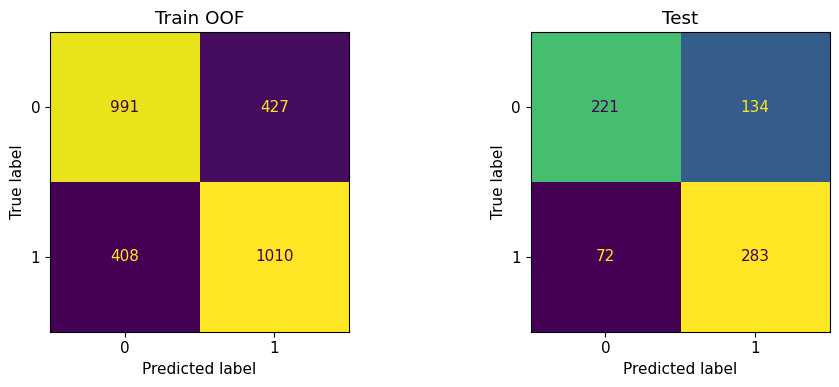

In [8]:
# ── 최종 Test set 평가 (1회만 실행)
from sklearn.model_selection import cross_val_predict

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc  = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
train_auc = gs.best_score_

print(f"Train CV AUC : {train_auc:.4f}")
print(f"Test AUC     : {test_auc:.4f}")
print(f"과적합 갭    : {train_auc - test_auc:+.4f}")

# OOF Confusion Matrix (Train 기준)
y_oof = cross_val_predict(final_model, X_train, y_train, cv=skf, method='predict')
print(f"\n[Train OOF] Classification Report:")
print(classification_report(y_train, y_oof))

# Test Confusion Matrix
print(f"[Test] Classification Report:")
print(classification_report(y_test, final_model.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_oof, ax=axes[0], colorbar=False)
axes[0].set_title("Train OOF")
ConfusionMatrixDisplay.from_predictions(y_test, final_model.predict(X_test), ax=axes[1], colorbar=False)
axes[1].set_title("Test")
plt.tight_layout()
plt.show()

In [11]:
# ── 최종 모델 저장
import pickle, os

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f"=== 최종 모델 성능 ===")
print(f"ml_v6  (PCA Y 기준)          : 0.7673")
print(f"ml_v11 (리뷰수 단독 Y)       : 0.7691")
print(f"ml_v12 (평점×리뷰수 복합 Y)  : {test_auc:.4f}")

save_dir = r"C:\workspace\finalproject\data\model_output"
os.makedirs(save_dir, exist_ok=True)

model_data = {
    'model':       final_model,
    'feat_cols':   feat_cols,
    'gt_map':      gt_map,
    'kbeauty_map': kbeauty_map,
    'y_type':      'composite_rating_x_review',
}
save_path = os.path.join(save_dir, 'lgbm_v12.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"\n모델 저장 완료: {save_path}")
print(f"저장 피처 수: {len(feat_cols)}개")

=== 최종 모델 성능 ===
ml_v6  (PCA Y 기준)          : 0.7673
ml_v11 (리뷰수 단독 Y)       : 0.7691
ml_v12 (평점×리뷰수 복합 Y)  : 0.7866

모델 저장 완료: C:\workspace\finalproject\data\model_output\lgbm_v12.pkl
저장 피처 수: 48개


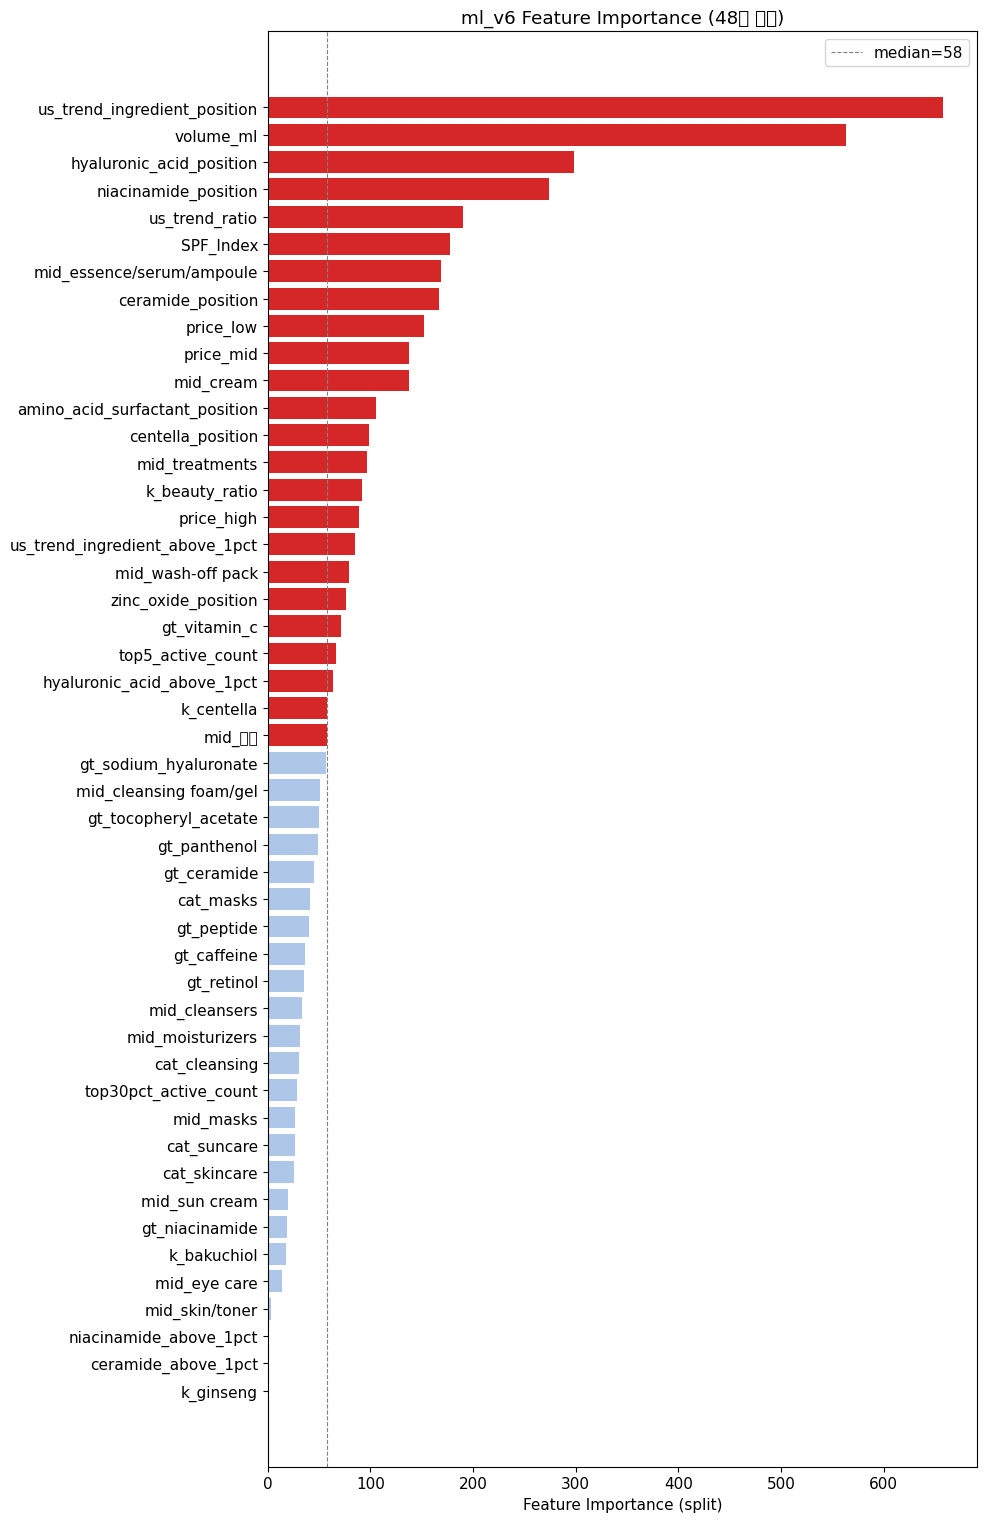


전체 피처 중요도 (내림차순):
us_trend_ingredient_position      658
volume_ml                         563
hyaluronic_acid_position          298
niacinamide_position              274
us_trend_ratio                    190
SPF_Index                         177
mid_essence/serum/ampoule         169
ceramide_position                 167
price_low                         152
price_mid                         138
mid_cream                         138
amino_acid_surfactant_position    105
centella_position                  99
mid_treatments                     97
k_beauty_ratio                     92
price_high                         89
us_trend_ingredient_above_1pct     85
mid_wash-off pack                  79
zinc_oxide_position                76
gt_vitamin_c                       71
top5_active_count                  66
hyaluronic_acid_above_1pct         63
k_centella                         58
mid_기타                             58
gt_sodium_hyaluronate              57
mid_cleansing foam/gel         

In [10]:
# ── 피처 Importance 시각화 (전체)
imp_series = pd.Series(final_model.feature_importances_, index=feat_cols).sort_values(ascending=True)

plt.figure(figsize=(10, len(feat_cols) * 0.32))
colors = ['#d62728' if v > imp_series.median() else '#aec7e8' for v in imp_series]
plt.barh(imp_series.index, imp_series.values, color=colors)
plt.axvline(imp_series.median(), color='gray', linestyle='--', linewidth=0.8, label=f'median={imp_series.median():.0f}')
plt.xlabel('Feature Importance (split)')
plt.title(f'ml_v6 Feature Importance ({len(feat_cols)}개 피처)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n전체 피처 중요도 (내림차순):")
print(imp_series.sort_values(ascending=False).to_string())